# Assignment #1 — Airbnb NYC 2018 EDA
This notebook reproduces the analysis and figures used in the PPT.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
csv_path = Path('Airbnb (1).csv')  # ensure the CSV is in the same folder as this notebook
df = pd.read_csv(csv_path)

# Align columns to assignment spec
col_map = {
    'id': 'Listing_id','name':'Listing_name','host_id':'Host_id','host_name':'Host_name',
    'neighbourhood_group':'Neighbourhood_group','neighbourhood':'Neighbourhood',
    'room_type':'Room_type','minimum_nights':'Minimum_nights',
    'number_of_reviews':'Total_reviews','reviews_per_month':'Reviews_per_month',
    'calculated_host_listings_count':'Host_listings_count','availability_365':'Availability_365',
    'price':'Price','latitude':'Latitude','longitude':'Longitude'
}
for src, dst in col_map.items():
    if src in df.columns and dst not in df.columns:
        df[dst] = df[src]
cols_wanted = ['Listing_id','Listing_name','Host_id','Host_name','Neighbourhood_group','Neighbourhood',
               'Latitude','Longitude','Room_type','Price','Minimum_nights','Total_reviews','Reviews_per_month',
               'Host_listings_count','Availability_365']
df = df[[c for c in cols_wanted if c in df.columns]].copy()
df.head()

,Host_id,Host_name,Neighbourhood_group,Neighbourhood,Latitude,Longitude,Room_type,Price,Minimum_nights,Reviews_per_month,Availability_365
0,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,0.21,365
1,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,0.38,355
2,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0.00,365
3,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,4.64,194
4,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,0.10,0


In [2]:
# Overview
df.describe(include='all')

,Host_id,Host_name,Neighbourhood_group,Neighbourhood,Latitude,Longitude,Room_type,Price,Minimum_nights,Reviews_per_month,Availability_365
count,4.588200e+04,45882,45882,45882,45882.000000,45882.000000,45882,45882.000000,45882.000000,45882.000000,45882.000000
unique,NaN,11006,5,219,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,NaN
freq,NaN,383,19484,3729,NaN,NaN,22769,NaN,NaN,NaN,NaN
mean,6.633487e+07,NaN,NaN,NaN,40.728478,-73.950729,NaN,119.947583,6.938887,1.108064,109.383506
std,7.757339e+07,NaN,NaN,NaN,0.055331,0.046475,NaN,68.112511,19.864751,1.612697,130.264161
min,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,0.000000
25%,7.719468e+06,NaN,NaN,NaN,40.689230,-73.981920,NaN,65.000000,1.000000,0.050000,0.000000
50%,3.028359e+07,NaN,NaN,NaN,40.721770,-73.954365,NaN,100.000000,2.000000,0.385000,39.000000
75%,1.055072e+08,NaN,NaN,NaN,40.763390,-73.934320,NaN,159.000000,5.000000,1.620000,216.750000


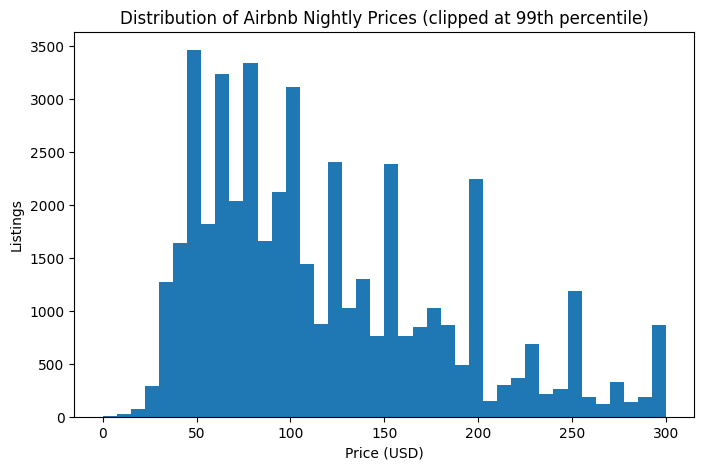

In [3]:
# Histogram of Price (clipped at 99th percentile for visibility)
clip = np.nanpercentile(df['Price'],99)
plt.figure(figsize=(8,5))
plt.hist(df.loc[df['Price'].between(0,clip),'Price'].dropna(), bins=40)
plt.title('Distribution of Airbnb Nightly Prices (clipped at 99th percentile)')
plt.xlabel('Price (USD)')
plt.ylabel('Listings')
plt.show()

In [4]:
# Listings per Neighbourhood Group
ng_counts = df['Neighbourhood_group'].value_counts().sort_values(ascending=False)
ng_counts

Neighbourhood_group
Manhattan        19484
Brooklyn         19400
Queens            5565
Bronx             1068
Staten Island      365
Name: count, dtype: int64

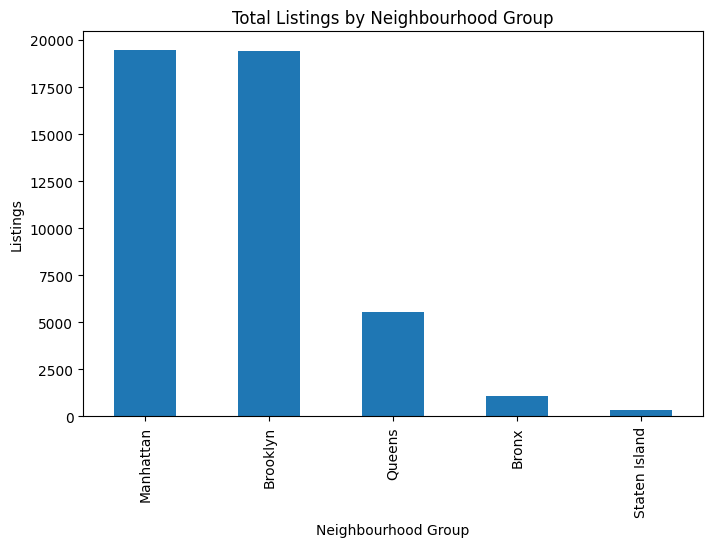

In [5]:
plt.figure(figsize=(8,5))
ng_counts.plot(kind='bar')
plt.title('Total Listings by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Listings')
plt.show()

In [6]:
# Costliest neighbourhood group (mean and median)
mean_prices = df.groupby('Neighbourhood_group')['Price'].mean().sort_values(ascending=False)
median_prices = df.groupby('Neighbourhood_group')['Price'].median().sort_values(ascending=False)
mean_prices, median_prices

(Neighbourhood_group
 Manhattan        145.894631
 Brooklyn         105.713454
 Staten Island     89.235616
 Queens            88.919317
 Bronx             77.318352
 Name: Price, dtype: float64,
 Neighbourhood_group
 Manhattan        135.0
 Brooklyn          90.0
 Staten Island     75.0
 Queens            74.0
 Bronx             65.0
 Name: Price, dtype: float64)

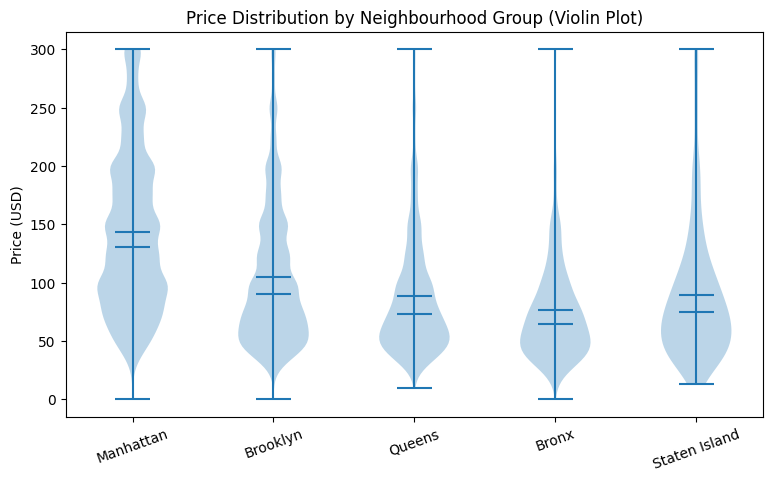

In [7]:
# Violin plot of price by neighbourhood group (clipped at 99th percentile)
order = df['Neighbourhood_group'].value_counts().index.tolist()
data = [df.loc[df['Neighbourhood_group']==ng,'Price'].dropna() for ng in order]
clip = np.nanpercentile(df['Price'],99)
data = [x[x.between(0,clip)] for x in data]
plt.figure(figsize=(9,5))
plt.violinplot(data, showmeans=True, showmedians=True)
plt.xticks(range(1,len(order)+1), order, rotation=20)
plt.title('Price Distribution by Neighbourhood Group (Violin Plot)')
plt.ylabel('Price (USD)')
plt.show()

In [8]:
# Room type options: counts and price summary
room_counts = df['Room_type'].value_counts()
room_summary = df.groupby('Room_type')['Price'].agg(['count','mean','median','min','max']).sort_values('count', ascending=False)
room_counts, room_summary

(Room_type
 Entire home/apt    22769
 Private room       21976
 Shared room         1137
 Name: count, dtype: int64,
                  count        mean  median  min  max
 Room_type                                           
 Entire home/apt  22769  162.479468   150.0    0  333
 Private room     21976   79.022297    70.0    0  333
 Shared room       1137   59.231310    45.0    0  320)

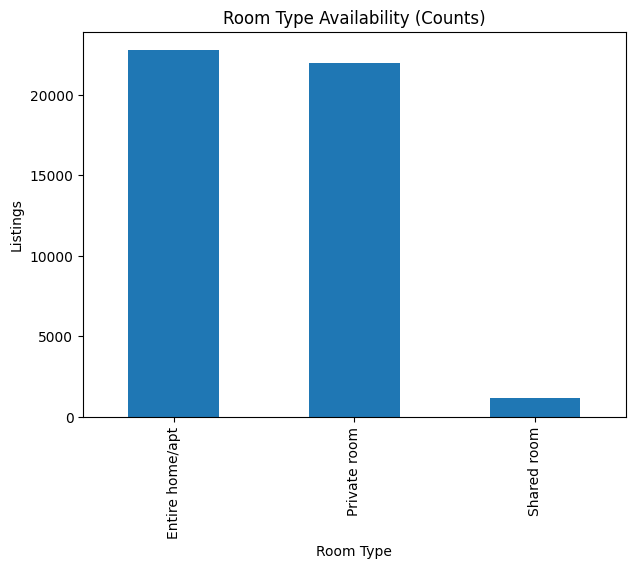

In [9]:
plt.figure(figsize=(7,5))
room_counts.plot(kind='bar')
plt.title('Room Type Availability (Counts)')
plt.xlabel('Room Type')
plt.ylabel('Listings')
plt.show()

C:\Users\lolim\AppData\Local\Temp\ipykernel_19896\2202988271.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=ordered, showmeans=True)


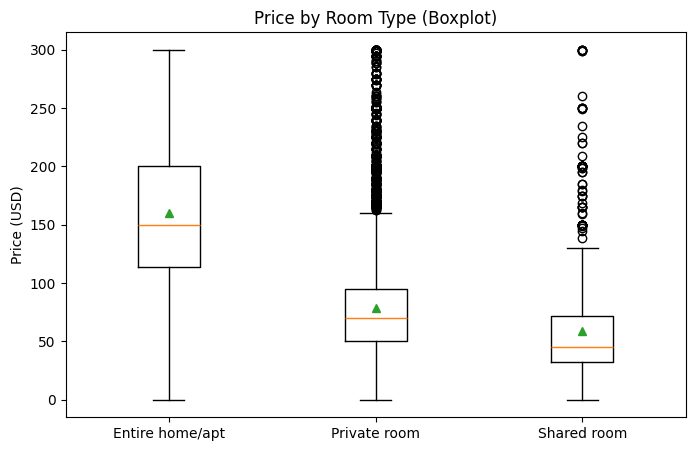

In [10]:
# Boxplot of price by room type (clipped at 99th percentile)
ordered = room_counts.index.tolist()
clip = np.nanpercentile(df['Price'],99)
data_box = [df.loc[df['Room_type']==rt,'Price'].dropna() for rt in ordered]
data_box = [x[x.between(0,clip)] for x in data_box]
plt.figure(figsize=(8,5))
plt.boxplot(data_box, labels=ordered, showmeans=True)
plt.title('Price by Room Type (Boxplot)')
plt.ylabel('Price (USD)')
plt.show()

In [11]:
# Month-long stay feasibility: Minimum_nights <= 30 and Availability_365 >= 30
min_ok = df['Minimum_nights'] <= 30
avail_ok = df['Availability_365'] >= 30 if 'Availability_365' in df.columns else True
feasible = df[min_ok & avail_ok]
total = len(df)
feasible_count = len(feasible)
feasible_pct = 100*feasible_count/total if total else np.nan
feasible_count, total, feasible_pct

(23594, 45882, 51.4232160760211)

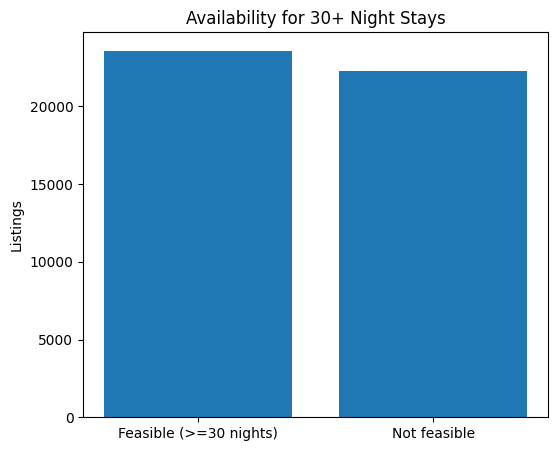

In [12]:
plt.figure(figsize=(6,5))
values = [feasible_count, total-feasible_count]
labels = ['Feasible (>=30 nights)','Not feasible']
plt.bar(labels, values)
plt.title('Availability for 30+ Night Stays')
plt.ylabel('Listings')
plt.show()

In [13]:
# OPTIONAL: Grouped bars — room type counts by neighbourhood group
grouped_rt = df.groupby(['Neighbourhood_group','Room_type']).size().unstack(fill_value=0)
grouped_rt

Room_type,Entire home/apt,Private room,Shared room
Neighbourhood_group,,,
Bronx,362,648,58
Brooklyn,8936,10053,411
Manhattan,11281,7738,465
Queens,2022,3349,194
Staten Island,168,188,9


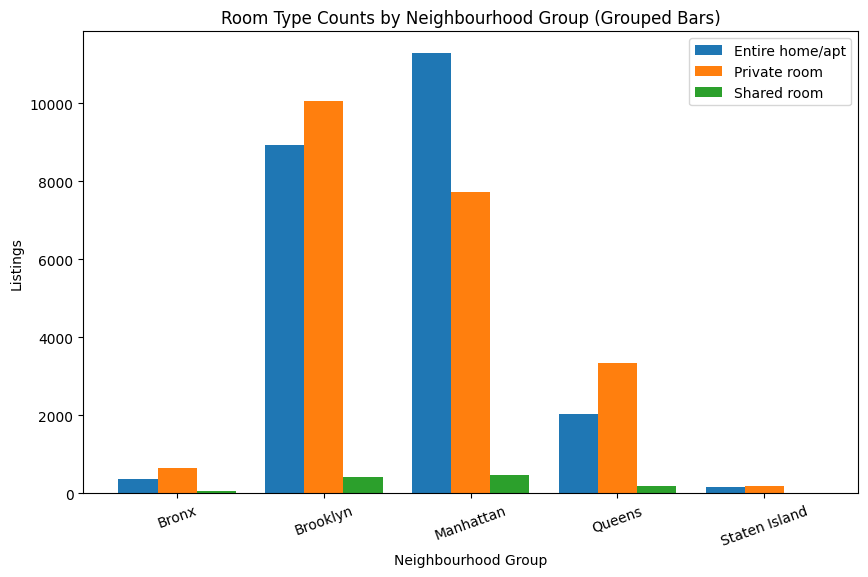

In [14]:
import numpy as np
plt.figure(figsize=(10,6))
idx = np.arange(len(grouped_rt.index))
width = 0.8/len(grouped_rt.columns) if len(grouped_rt.columns)>0 else 0.2
for i, col in enumerate(grouped_rt.columns):
    plt.bar(idx + i*width, grouped_rt[col].values, width=width, label=str(col))
plt.xticks(idx + (len(grouped_rt.columns)-1)*width/2, grouped_rt.index, rotation=20)
plt.title('Room Type Counts by Neighbourhood Group (Grouped Bars)')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Listings')
plt.legend()
plt.show()

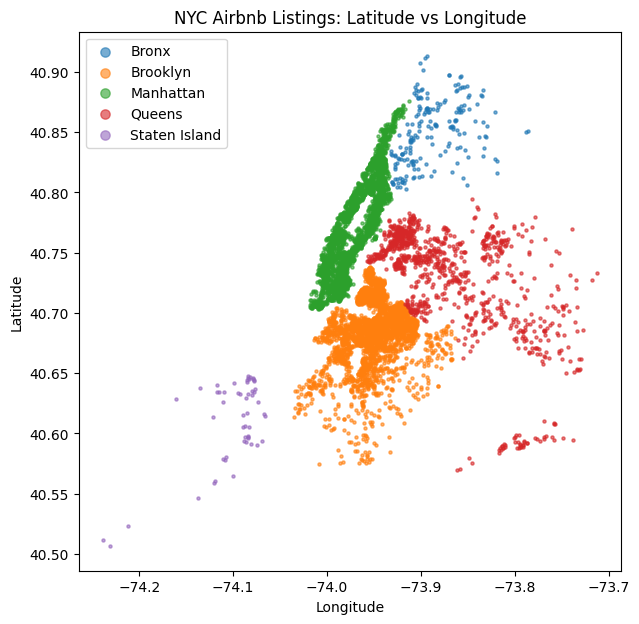

In [15]:
# OPTIONAL: Scatter map of Lat/Lon
plot_df = df.sample(n=min(8000, len(df)), random_state=42) if len(df)>8000 else df.copy()
plt.figure(figsize=(7,7))
if 'Neighbourhood_group' in plot_df.columns:
    for ng, sub in plot_df.groupby('Neighbourhood_group'):
        plt.scatter(sub['Longitude'], sub['Latitude'], s=5, alpha=0.6, label=str(ng))
    plt.legend(markerscale=3)
else:
    plt.scatter(plot_df['Longitude'], plot_df['Latitude'], s=5, alpha=0.6)
plt.title('NYC Airbnb Listings: Latitude vs Longitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()